# **Thyriod Risk Prediction Model**
Performing KMeans analysis of Thyroid Patient dataset for risk assesement and prediction in an optimal manner.

## Data Analysis

### 1. General Imports

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, normalized_mutual_info_score, adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.cluster import KMeans

### 2. Loading the **Dataset**

In [3]:
df = pd.read_csv(r"C:\Users\Lasya\Downloads\Thyroid_Diff.csv")

In [4]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [5]:
print(df)

     Age Gender Smoking Hx Smoking Hx Radiothreapy          Thyroid Function  \
0     27      F      No         No              No                 Euthyroid   
1     34      F      No        Yes              No                 Euthyroid   
2     30      F      No         No              No                 Euthyroid   
3     62      F      No         No              No                 Euthyroid   
4     62      F      No         No              No                 Euthyroid   
..   ...    ...     ...        ...             ...                       ...   
378   72      M     Yes        Yes             Yes                 Euthyroid   
379   81      M     Yes         No             Yes                 Euthyroid   
380   72      M     Yes        Yes              No                 Euthyroid   
381   61      M     Yes        Yes             Yes  Clinical Hyperthyroidism   
382   67      M     Yes         No              No                 Euthyroid   

            Physical Examination Adenop

In [6]:
print(df.shape)

(383, 17)


In [7]:
print(df.value_counts)

<bound method DataFrame.value_counts of      Age Gender Smoking Hx Smoking Hx Radiothreapy          Thyroid Function  \
0     27      F      No         No              No                 Euthyroid   
1     34      F      No        Yes              No                 Euthyroid   
2     30      F      No         No              No                 Euthyroid   
3     62      F      No         No              No                 Euthyroid   
4     62      F      No         No              No                 Euthyroid   
..   ...    ...     ...        ...             ...                       ...   
378   72      M     Yes        Yes             Yes                 Euthyroid   
379   81      M     Yes         No             Yes                 Euthyroid   
380   72      M     Yes        Yes              No                 Euthyroid   
381   61      M     Yes        Yes             Yes  Clinical Hyperthyroidism   
382   67      M     Yes         No              No                 Euthyroid   


### 3. Droping **Duplicate** Data from the dataframe

In [8]:
df.drop_duplicates(inplace=True)
print(df[df.duplicated].shape)

(0, 17)


In [9]:
df_null_rows= df.isnull
print(df_null_rows)

<bound method DataFrame.isnull of      Age Gender Smoking Hx Smoking Hx Radiothreapy          Thyroid Function  \
0     27      F      No         No              No                 Euthyroid   
1     34      F      No        Yes              No                 Euthyroid   
2     30      F      No         No              No                 Euthyroid   
3     62      F      No         No              No                 Euthyroid   
4     62      F      No         No              No                 Euthyroid   
..   ...    ...     ...        ...             ...                       ...   
378   72      M     Yes        Yes             Yes                 Euthyroid   
379   81      M     Yes         No             Yes                 Euthyroid   
380   72      M     Yes        Yes              No                 Euthyroid   
381   61      M     Yes        Yes             Yes  Clinical Hyperthyroidism   
382   67      M     Yes         No              No                 Euthyroid   

     

### 4. **Preprocessing** Data by setting **targets** and **encoding**

In [10]:
features = [
    'Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
    'Thyroid Function', 'Physical Examination', 'Adenopathy',
    'Pathology', 'Focality', 'T', 'N', 'M', 'Stage'
]

x = df[features]
x_encoded = pd.get_dummies(x)

In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in x_encoded.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()
    x_encoded[column] = le.fit_transform(x_encoded[column].astype(str))
    label_encoders[column] = le

### 5. **Scaling** the encoded data

In [13]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_encoded)

## **KMeans** Algorithm

### 1. Setting the **Range** and **Evaluation Metrics**

In [14]:
k_range = range(2, 11)
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

In [15]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=82, n_init=10)
    clusters = kmeans.fit_predict(x_scaled)

    silhouette_scores.append(silhouette_score(x_scaled, clusters))
    davies_bouldin_scores.append(davies_bouldin_score(x_scaled, clusters))
    calinski_harabasz_scores.append(calinski_harabasz_score(x_scaled, clusters))

optimal_k = k_range[np.argmax(silhouette_scores)]

C:\Users\Lasya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lasya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lasya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lasya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

### 2. Dtermining the **optimal** value for k

In [16]:
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=82, n_init=10)
    clusters = kmeans.fit_predict(x_scaled)

    silhouette_scores.append(silhouette_score(x_scaled, clusters))
    davies_bouldin_scores.append(davies_bouldin_score(x_scaled, clusters))
    calinski_harabasz_scores.append(calinski_harabasz_score(x_scaled, clusters))

C:\Users\Lasya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lasya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lasya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lasya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

In [17]:
print(optimal_k)

2


## **Data Visualization**

### 1. Plotting the **Evaluation Metric Analysis** of the optimal value of k

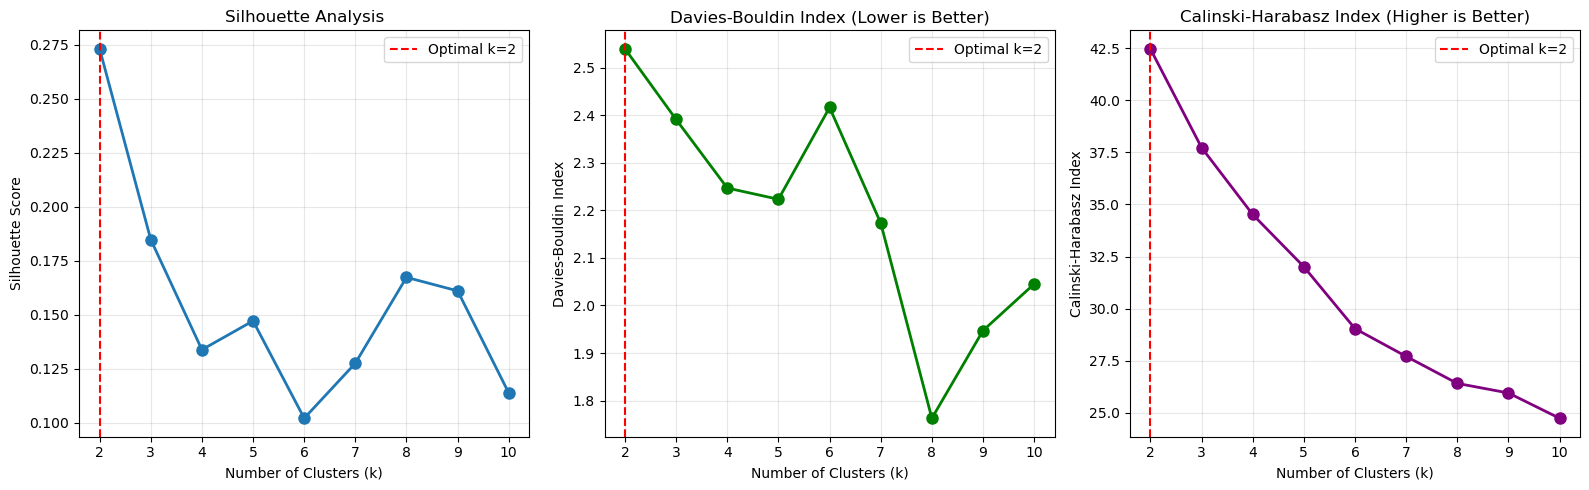

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Analysis')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, davies_bouldin_scores, marker='o', linewidth=2, markersize=8, color='green')
axes[1].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index (Lower is Better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_range, calinski_harabasz_scores, marker='o', linewidth=2, markersize=8, color='purple')
axes[2].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Index')
axes[2].set_title('Calinski-Harabasz Index (Higher is Better)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Prediction with Clusters**

In [19]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(x_scaled)

C:\Users\Lasya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [20]:
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels


In [21]:
print(df_clustered['Cluster'].value_counts().sort_index())


Cluster
0     60
1    304
Name: count, dtype: int64


In [22]:
risk_to_num = {'Low': 0, 'Intermediate': 1, 'High': 2}
num_to_risk = {0: 'Low', 1: 'Intermediate', 2: 'High'}

cluster_risk_profiles = {}

for cluster_id in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
    risk_dist = cluster_data['Risk'].value_counts()
    dominant_risk = cluster_data['Risk'].mode()[0]

    cluster_risk_profiles[cluster_id] = dominant_risk

    print(f"\nCluster {cluster_id} (n={len(cluster_data)}):")
    print(f"  Risk Distribution:")
    for risk_level in ['Low', 'Intermediate', 'High']:
        count = (cluster_data['Risk'] == risk_level).sum()
        pct = (count / len(cluster_data)) * 100
        print(f"    {risk_level}: {count:3d} ({pct:5.1f}%)")
    print(f"  → Dominant Risk: {dominant_risk}")
    print(f"  → Mean Age: {cluster_data['Age'].mean():.1f}")
    print(f"  → Recurrence Rate: {(cluster_data['Recurred'] == 'Yes').sum() / len(cluster_data) * 100:.1f}%")



Cluster 0 (n=60):
  Risk Distribution:
    Low:   2 (  3.3%)
    Intermediate:  30 ( 50.0%)
    High:  28 ( 46.7%)
  → Dominant Risk: Intermediate
  → Mean Age: 56.3
  → Recurrence Rate: 90.0%

Cluster 1 (n=304):
  Risk Distribution:
    Low: 228 ( 75.0%)
    Intermediate:  72 ( 23.7%)
    High:   4 (  1.3%)
  → Dominant Risk: Low
  → Mean Age: 38.3
  → Recurrence Rate: 17.8%


In [23]:
cluster_to_risk = cluster_risk_profiles

# Predict risk for all samples
predicted_risk = df_clustered['Cluster'].map(cluster_to_risk)

print(f"\n✓ Cluster-to-Risk Mapping:")
for cluster_id, risk in cluster_to_risk.items():
    print(f"  Cluster {cluster_id} → {risk}")

print(f"\n✓ Predicted Risk Distribution:")
print(predicted_risk.value_counts())


✓ Cluster-to-Risk Mapping:
  Cluster 0 → Intermediate
  Cluster 1 → Low

✓ Predicted Risk Distribution:
Cluster
Low             304
Intermediate     60
Name: count, dtype: int64


## **Evaluation of the Prediction Model**

### 1. **Sihouette**, **NMI**, **Calinski-Harabasz**, **Adjusted Rand Index**, **Davies-Bouldin Index** Metrics of Evaluation

> Add blockquote



In [24]:
risk_encoded = pd.factorize(df_clustered['Risk'])[0]
nmi = normalized_mutual_info_score(risk_encoded, cluster_labels)
ari = adjusted_rand_score(risk_encoded, cluster_labels)
silhouette = silhouette_score(x_scaled, cluster_labels)
davies_bouldin = davies_bouldin_score(x_scaled, cluster_labels)
calinski_harabasz = calinski_harabasz_score(x_scaled, cluster_labels)

print(f"\n✓ CLUSTERING QUALITY METRICS:")
print(f"  Silhouette Score:              {silhouette:.4f}")
print(f"  Davies-Bouldin Index:          {davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index:       {calinski_harabasz:.2f}")
print(f"  Normalized Mutual Information: {nmi:.4f}")
print(f"  Adjusted Rand Index:           {ari:.4f}")


✓ CLUSTERING QUALITY METRICS:
  Silhouette Score:              0.3128
  Davies-Bouldin Index:          2.4218
  Calinski-Harabasz Index:       43.05
  Normalized Mutual Information: 0.3260
  Adjusted Rand Index:           0.3642


### 2. **Accuracy**, **Confusion Matrix** and **F-1** score for the model

In [25]:
predicted_risk_numeric = predicted_risk.map(risk_to_num)
actual_risk_numeric = df_clustered['Risk'].map(risk_to_num)

accuracy = accuracy_score(actual_risk_numeric, predicted_risk_numeric)
f1 = f1_score(actual_risk_numeric, predicted_risk_numeric, average='weighted')

print(f"\n✓ RISK PREDICTION PERFORMANCE:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(actual_risk_numeric, predicted_risk_numeric)
print(f"\n✓ CONFUSION MATRIX:")
print(cm)


✓ RISK PREDICTION PERFORMANCE:
  Accuracy:  0.7088 (70.88%)
  F1-Score:  0.6434

✓ CONFUSION MATRIX:
[[228   2   0]
 [ 72  30   0]
 [  4  28   0]]


## Using **Principal Component Analysis** for data reduction and visualization

In [26]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
plt.show()

<Figure size 1800x1200 with 0 Axes>

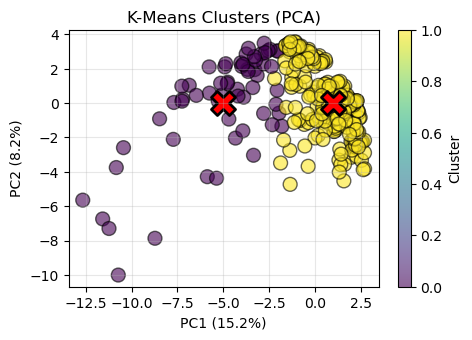

In [27]:
ax1 = fig.add_subplot(gs[0, 0])

scatter1 = ax1.scatter(
    x_pca[:, 0], x_pca[:, 1],
    c=cluster_labels,
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='black'
)

centers_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker='X',
    s=300,
    c='red',
    edgecolors='black',
    linewidth=2
)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax1.set_title('K-Means Clusters (PCA)')
ax1.grid(True, alpha=0.3)

fig.colorbar(scatter1, ax=ax1, label='Cluster')
plt.show()
display(fig)

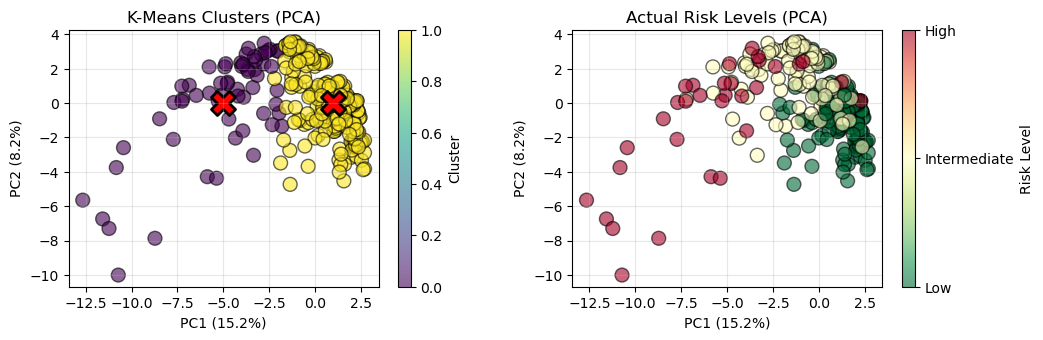

In [28]:
ax2 = fig.add_subplot(gs[0, 1])

risk_map = {'Low': 0, 'Intermediate': 1, 'High': 2}
risk_numeric = df_clustered['Risk'].map(risk_map)

scatter2 = ax2.scatter(
    x_pca[:, 0], x_pca[:, 1],
    c=risk_numeric,
    cmap='RdYlGn_r',
    s=100,
    alpha=0.6,
    edgecolors='black'
)

ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax2.set_title('Actual Risk Levels (PCA)')
ax2.grid(True, alpha=0.3)

cbar = fig.colorbar(scatter2, ax=ax2, label='Risk Level')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['Low', 'Intermediate', 'High'])
plt.show()
display(fig)

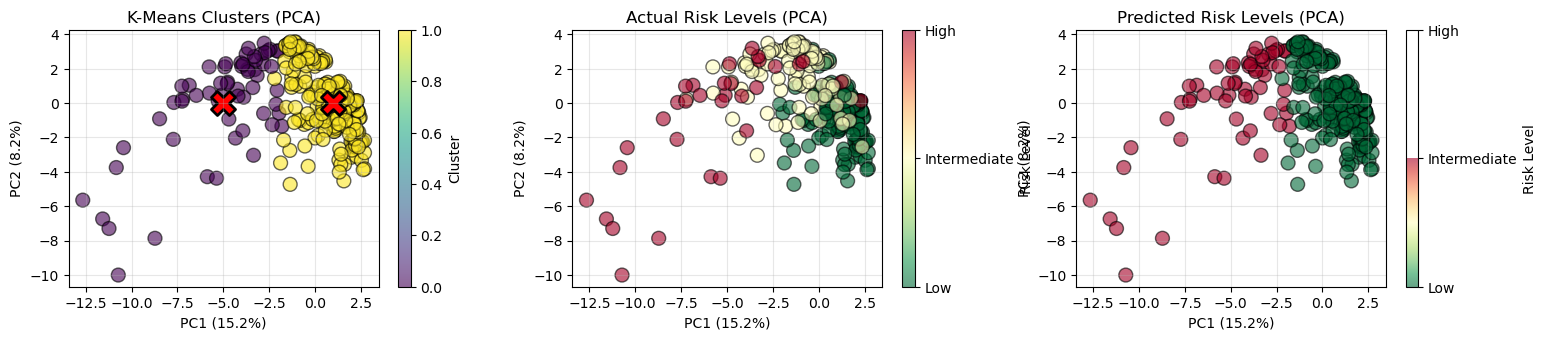

In [29]:
ax3 = fig.add_subplot(gs[0, 2])

pred_numeric = predicted_risk.map(risk_map)

scatter3 = ax3.scatter(
    x_pca[:, 0], x_pca[:, 1],
    c=pred_numeric,
    cmap='RdYlGn_r',
    s=100,
    alpha=0.6,
    edgecolors='black'
)

ax3.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax3.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax3.set_title('Predicted Risk Levels (PCA)')
ax3.grid(True, alpha=0.3)

# ✅ Correct colorbar
cbar = fig.colorbar(scatter3, ax=ax3, label='Risk Level')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['Low', 'Intermediate', 'High'])
from IPython.display import display
display(fig)

In [30]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [31]:
joblib.dump(x_encoded.columns, "columns_kmeans.pkl")

['columns_kmeans.pkl']

In [32]:
joblib.dump(scaler, "scaler_kmeans.pkl")

['scaler_kmeans.pkl']

### Risk Stratification using KMeans Clustering

KMeans clustering was used to segment patients into distinct risk groups based on clinical features.

The optimal number of clusters was determined using evaluation metrics such as Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score.

Each cluster was then mapped to a clinical risk category (Low, Intermediate, High) based on the dominant risk label within the cluster.

This approach enables interpretable patient segmentation and helps identify groups with higher recurrence likelihood.